# Proyecto Integrador EH1023
El metodo empleado para realizar este reporte de investigación será:
> **Pregunta → Capturar → Procesar → Visualizar → Interpretar**
## Pregutna de investigación
¿En los últimos 10 años, cuántos libros en español aparecen en OpenLibrary?
¿Qué características tienen estoy libros?

### Fuente de Información:
API de OpenLibrary: https://openlibrary.org/search.json

In [49]:
# Librerías
import requests
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import json
import time

# Captura de datos
Uso de la API de OpenLibrary

In [ ]:

url_base = "https://openlibrary.org/search.json"

# La sintaxis correcta: todo va dentro del parámetro 'q'
parametros = {
    "q": "language:spa first_publish_year:[2025 TO 2026]",
    "sort": "new",
    "limit": 1000,  # Máximo permitido por página (1000)
    "offset": 0 
}

headers = {
    "User-Agent": "MiAppDeLibros/1.0 ()"
}

todos_los_libros = []
num_paginas = 8

for pagina in range(num_paginas):
    parametros["offset"] = pagina * 1000
    
    try:
        respuesta = requests.get(url_base, params=parametros, headers=headers, timeout=60)
        
        if respuesta.status_code == 200:
            datos = respuesta.json()
            libros = datos.get('docs', [])
            
            if not libros:  # Si no hay más resultados, salir del bucle
                break
                
            for libro in libros:
                autor = ", ".join(libro.get("author_name", ["Desconocido"]))
                titulo = libro.get("title", "Sin título")
                anio = libro.get("first_publish_year", "N/A")
                
                todos_los_libros.append({
                    "autor": autor,
                    "titulo": titulo,
                    "anio_publicacion": anio
                })
            
            print(f"Página {pagina + 1}: {len(libros)} libros obtenidos")
            
            # Pausa para no sobrecargar el servidor
            time.sleep(35)
        else:
            print(f"Error en página {pagina + 1}: {respuesta.status_code}")
            break
            
    except Exception as e:
        print(f"Error: {e}")
        break

# Para el código se empleó TecGPT y Gemini

Página 1: 1000 libros obtenidos
Página 2: 1000 libros obtenidos
Página 3: 994 libros obtenidos


# Procesar
Se crea un dataframe

In [59]:
df = pd.DataFrame(todos_los_libros)
print(f"\nTotal de libros obtenidos: {len(df)}")
df.head(10)


Total de libros obtenidos: 2994


,autor,titulo,anio_publicacion
0,Andeka Larrea,Una caída titánica,2026
1,Carlos Altamirano-Morales,El rock de Chihuahua en mi vida,2026
2,Rodrigo Unda,Cuando vi a la muerte prestar su sombrero,2026
3,Fernando Rueda,No me llames traidor,2026
4,Edgardo Dobry,América en sus poetas,2026
5,Fernando Aramburu,Maite,2026
6,Sergio del Molino,La hija,2026
7,Desconocido,El pensamiento latinoamericano en el siglo XXI,2026
8,Leticia Álvarez,Trashorras,2026
9,Olga Kawecka,Песни с того света,2026


## Añadir el género del autor(a) mediante genderize.io

In [62]:
API_KEY = "02cea41838157999ae625218becd5dae"

In [ ]:
def obtener_genero(nombre):
    url = "https://api.genderize.io"
    params = {"name": nombre, "apikey": }
    try:
        response = requests.get(url, params=params)
        if response.status_code == 200:
            data = response.json()
            return data.get("gender", "Desconocido")  # Devuelve 'female', 'male' o 'Desconocido'
        else:
            return "Desconocido"
    except Exception as e:
        print(f"Error al consultar género para {nombre}: {e}")
        return "Desconocido"


In [ ]:
df["primer_nombre"] = df["autor"].apply(lambda x: x.split()[0])  # Toma el primer nombre

In [67]:
df.head(10)

,autor,titulo,anio_publicacion,primer_nombre
0,Andeka Larrea,Una caída titánica,2026,Andeka
1,Carlos Altamirano-Morales,El rock de Chihuahua en mi vida,2026,Carlos
2,Rodrigo Unda,Cuando vi a la muerte prestar su sombrero,2026,Rodrigo
3,Fernando Rueda,No me llames traidor,2026,Fernando
4,Edgardo Dobry,América en sus poetas,2026,Edgardo
5,Fernando Aramburu,Maite,2026,Fernando
6,Sergio del Molino,La hija,2026,Sergio
7,Desconocido,El pensamiento latinoamericano en el siglo XXI,2026,Desconocido
8,Leticia Álvarez,Trashorras,2026,Leticia
9,Olga Kawecka,Песни с того света,2026,Olga


In [70]:
df["genero_genderize.io"] = df["primer_nombre"].apply(obtener_genero)

In [71]:
df.head(10)

,autor,titulo,anio_publicacion,primer_nombre,genero_genderize.io
0,Andeka Larrea,Una caída titánica,2026,Andeka,male
1,Carlos Altamirano-Morales,El rock de Chihuahua en mi vida,2026,Carlos,male
2,Rodrigo Unda,Cuando vi a la muerte prestar su sombrero,2026,Rodrigo,male
3,Fernando Rueda,No me llames traidor,2026,Fernando,male
4,Edgardo Dobry,América en sus poetas,2026,Edgardo,male
5,Fernando Aramburu,Maite,2026,Fernando,male
6,Sergio del Molino,La hija,2026,Sergio,male
7,Desconocido,El pensamiento latinoamericano en el siglo XXI,2026,Desconocido,male
8,Leticia Álvarez,Trashorras,2026,Leticia,female
9,Olga Kawecka,Песни с того света,2026,Olga,female


In [72]:
# Guardamos el dataframe
df.to_csv("libros_gen.csv", index=False, encoding="utf-8")

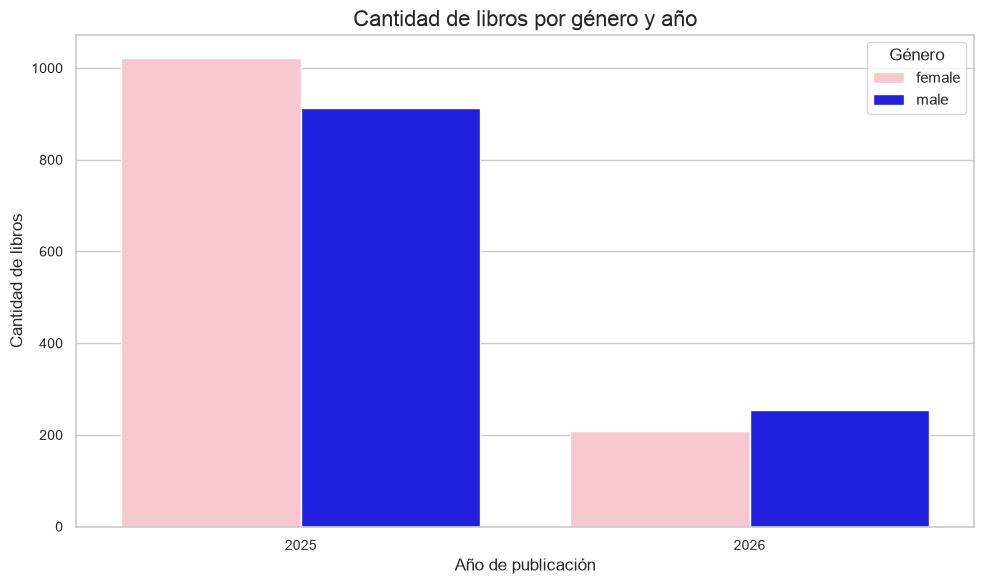

In [73]:
df.rename(columns={"genero_genderize.io": "genero"}, inplace=True)

# Filtrar las entradas con autor "Desconocido" o género "Desconocido"
df_filtrado = df[(df["autor"] != "Desconocido") & (df["genero"] != "Desconocido")]

# Contar libros por año y género
conteo = df_filtrado.groupby(["anio_publicacion", "genero"]).size().reset_index(name="cantidad")

# Configurar el estilo de Seaborn
sns.set(style="whitegrid")

# Crear una gráfica de barras
plt.figure(figsize=(10, 6))
sns.barplot(
    data=conteo, 
    x="anio_publicacion", 
    y="cantidad", 
    hue="genero", 
    palette={"male": "blue", "female": "pink"}
)

# Añadir etiquetas y título
plt.title("Cantidad de libros por género y año", fontsize=16)
plt.xlabel("Año de publicación", fontsize=12)
plt.ylabel("Cantidad de libros", fontsize=12)
plt.legend(title="Género")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Mostrar la gráfica
plt.tight_layout()
plt.show()